## Load necessary libraries

In [1]:
# import necessary libraries
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from cmcrameri import cm
import cartopy as cy
import cartopy.crs as ccrs
import cartopy.feature as cf
import os
from glob import glob
from functools import partial
import pickle
from matplotlib.table import Table
import numpy.ma as ma
from sklearn.metrics import mean_squared_error
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import dask
import pandas as pd
import concurrent.futures

## Initialize overarching dataset

In [2]:
atm_si_model_var = {
    'Tl1': {'standard_name': 'air_temperature_lowest_model_level', 'long_name': 'Air temperature at the lowest model level', 'units': 'K'},
    'T2M': {'standard_name': '2m_air_temperature', 'long_name': 'Air temperature at 2m', 'units': 'K'},
    'T0M': {'standard_name': '0m_air_temperature', 'long_name': 'Air temperature at 0m (based on temperature averaging)', 'units': 'K'},
    'Ts': {'standard_name': 'surface_temperature', 'long_name': 'Surface temperature (based on radiation)', 'units': 'K'},
    'Tice': {'standard_name': 'interface_snow_ice_temperature', 'long_name': 'Temperature at the snow/ice interface', 'units': 'K'},
    'SST': {'standard_name': 'sea_surface_temperature', 'long_name': 'Sea surface temperature', 'units': 'K'},
    'Wspeed': {'standard_name': 'wind_speed', 'long_name': 'Wind Speed', 'units': 'm/s'},
    'Wdirection': {'standard_name': 'wind_direction', 'long_name': 'Wind Direction', 'units': 'degrees'},
    'U10M': {'standard_name': 'eastward_wind_10m', 'long_name': 'Eastward wind at 10m', 'units': 'm/s'},
    'V10M': {'standard_name': 'northward_wind_10m', 'long_name': 'Northward wind at 10m', 'units': 'm/s'},
    'Ul1': {'standard_name': 'eastward_wind_lowest_model_level', 'long_name': 'Eastward wind at the lowest model level', 'units': 'm/s'},
    'Vl1': {'standard_name': 'northward_wind_lowest_model_level', 'long_name': 'Northward wind at the lowest model level', 'units': 'm/s'},
    'SIC': {'standard_name': 'sea_ice_concentration', 'long_name': 'Sea ice concentration (fraction)', 'units': '%'},
    'Uice': {'standard_name': 'sea_ice_eastward_velocity', 'long_name': 'Eastward sea ice velocity', 'units': 'm/s'},
    'Vice': {'standard_name': 'sea_ice_northward_velocity', 'long_name': 'Northward sea ice velocity', 'units': 'm/s'},
    'Hice': {'standard_name': 'sea_ice_thickness', 'long_name': 'Sea ice thickness', 'units': 'm'},
    'Sd': {'standard_name': 'snow_depth', 'long_name': 'Snow depth', 'units': 'm'},
    'sldr': {'standard_name': 'surface_downwelling_longwave_flux', 'long_name': 'Surface longwave downwelling radiation', 'units': 'W/m²'},
    'slur': {'standard_name': 'surface_upwelling_longwave_flux', 'long_name': 'Surface longwave upwelling radiation', 'units': 'W/m²'},
    'ssdr': {'standard_name': 'surface_downwelling_shortwave_flux', 'long_name': 'Surface shortwave downwelling radiation', 'units': 'W/m²'},
    'ssur': {'standard_name': 'surface_upwelling_shortwave_flux', 'long_name': 'Surface shortwave upwelling radiation', 'units': 'W/m²'}
}


In [3]:
# Make ONE dataset that saves all the relevant data for all the different models
model_names = ['MET-AROMEArctic', 'ECCC-HRDPSN', 'ECCC-HRDPSNcoupled','MF-AROME', 'DWD-ICON', 'ECMWF-IFS', 'ECMWF-AIFS', 'MF-ARPEGE','MET-Bris']
start_dt = datetime(2024, 4, 1)
tr_nr_values = [x for x in range(1, 36) if x not in [5, 33]]
lt_int_values = [']'+str(i)+'_'+str(i+12)+']' for i in range(0,90,12)]
time_values = [start_dt + timedelta(minutes=30*i) for i in range(0,61*24*2+1)]  # 61 days * 24 hours per day * 2 (per half hour)


In [4]:
# Create an empty DataArray with the required dimensions and NaN values
coords = {'model': model_names, 'lt_int': lt_int_values, 'tr_nr': tr_nr_values, 'time_ds': time_values}

# Utility function to create a DataArray with specified attributes
def create_dataarray(dims, shape, attrs):
    data = np.full(shape, np.nan, dtype=float)
    return xr.DataArray(data, coords={dim: coords[dim] for dim in dims}, dims=dims, attrs=attrs)

# Initialize dataset with specified variables for tr_nr and time only
data_vars = {
    'lat_obs': create_dataarray(['tr_nr', 'time_ds'], (len(tr_nr_values), len(time_values)), {'long_name': 'Latitude observations', 'units': 'degrees_north'}),
    'lon_obs': create_dataarray(['tr_nr', 'time_ds'], (len(tr_nr_values), len(time_values)), {'long_name': 'Longitude observations', 'units': 'degrees_east'}),
    'temp_1m_calibrated': create_dataarray(['tr_nr', 'time_ds'], (len(tr_nr_values), len(time_values)), {'long_name': 'Calibrated temperature at 1m', 'units': 'K'}),
    'temp_10cm_calibrated': create_dataarray(['tr_nr', 'time_ds'], (len(tr_nr_values), len(time_values)), {'long_name': 'Calibrated temperature at 10cm', 'units': 'K'}),
    'temp_snowsurface_calibrated': create_dataarray(['tr_nr', 'time_ds'], (len(tr_nr_values), len(time_values)), {'long_name': 'Calibrated temperature at snow surface', 'units': 'K'}),
    'temp_snowice_calibrated': create_dataarray(['tr_nr', 'time_ds'], (len(tr_nr_values), len(time_values)), {'long_name': 'Calibrated temperature at snow/ice interface', 'units': 'K'}),
    'AMSR2_SIC': create_dataarray(['tr_nr', 'time_ds'], (len(tr_nr_values), len(time_values)), {'long_name': 'AMSR2 sea ice concentration', 'units': '%'}),
    'MODIS_Ts': create_dataarray(['tr_nr', 'time_ds'], (len(tr_nr_values), len(time_values)), {'long_name': 'MODIS surface temperature', 'units': 'K'}),
}

# Add atmospheric single model variables to the dataset
for var_name, attributes in atm_si_model_var.items():
    data_vars[var_name] = create_dataarray(['model', 'lt_int', 'tr_nr', 'time_ds'], 
                                           (len(model_names), len(lt_int_values), len(tr_nr_values), len(time_values)), attributes)

# Create the dataset
dataset = xr.Dataset(data_vars)



In [5]:
dataset

<xarray.Dataset> Size: 1GB
Dimensions:                      (tr_nr: 33, time_ds: 2929, model: 9, lt_int: 8)
Coordinates:
  * tr_nr                        (tr_nr) int64 264B 1 2 3 4 6 ... 30 31 32 34 35
  * time_ds                      (time_ds) datetime64[ns] 23kB 2024-04-01 ......
  * model                        (model) <U18 648B 'MET-AROMEArctic' ... 'MET...
  * lt_int                       (lt_int) <U7 224B ']0_12]' ... ']84_96]'
Data variables: (12/29)
    lat_obs                      (tr_nr, time_ds) float64 773kB nan nan ... nan
    lon_obs                      (tr_nr, time_ds) float64 773kB nan nan ... nan
    temp_1m_calibrated           (tr_nr, time_ds) float64 773kB nan nan ... nan
    temp_10cm_calibrated         (tr_nr, time_ds) float64 773kB nan nan ... nan
    temp_snowsurface_calibrated  (tr_nr, time_ds) float64 773kB nan nan ... nan
    temp_snowice_calibrated      (tr_nr, time_ds) float64 773kB nan nan ... nan
    ...                           ...
    Hice                         (model, lt_int, tr_nr, time_ds) float64 56MB ...
    Sd                           (model, lt_int, tr_nr, time_ds) float64 56MB ...
    sldr                         (model, lt_int, tr_nr, time_ds) float64 56MB ...
    slur                         (model, lt_int, tr_nr, time_ds) float64 56MB ...
    ssdr                         (model, lt_int, tr_nr, time_ds) float64 56MB ...
    ssur                         (model, lt_int, tr_nr, time_ds) float64 56MB ...

## Fill overarching dataset with buoy data

In [6]:
f = open('dr.pkl', 'rb')
dr = pickle.load(f)
f.close()

In [7]:
for selected_tr_nr in tr_nr_values:
    
    # Nearest observed position (in time, to full hour, if available)
    # Nearest-Neighbour interpolation with mask for closeness
    lon_obs = dr[selected_tr_nr]['lon']
    lat_obs = dr[selected_tr_nr]['lat']
    time_pos_obs = dr[selected_tr_nr]['lon']['time']
    
    lon_obs_interp = lon_obs.interp(time=dataset.time_ds, method = 'nearest')
    lat_obs_interp = lat_obs.interp(time=dataset.time_ds, method = 'nearest')
    time_diff = np.abs((dataset.time_ds - time_pos_obs) / np.timedelta64(1, 'h'))
    min_time_diff = np.min(time_diff, axis=1)
    mask_obs_pos = (min_time_diff < 0.15).values
            
    lon_obs_interp = lon_obs_interp.where(mask_obs_pos, np.nan)
    lat_obs_interp = lat_obs_interp.where(mask_obs_pos, np.nan)
    
    dataset['lon_obs'].loc[dict(tr_nr=selected_tr_nr)] = lon_obs_interp
    dataset['lat_obs'].loc[dict(tr_nr=selected_tr_nr)] = lat_obs_interp
    
    
    # Nearest temperature observations (in time, to full hour, if available)
    # Convert degrees Celcius to degrees Kelvin
    temp_1m_calibrated = dr[selected_tr_nr]['temp_1m_calibrated'] + 273.15
    temp_10cm_calibrated = dr[selected_tr_nr]['temp_10cm_calibrated'] + 273.15
    temp_snowsurface_calibrated = dr[selected_tr_nr]['temp_snowsurface_calibrated'] + 273.15
    temp_snowice_calibrated = dr[selected_tr_nr]['temp_snowice_calibrated'] + 273.15
    time_temp = dr[selected_tr_nr]['temp_1m_calibrated']['time_temp']
    
    temp_1m_calibrated_interpolated = temp_1m_calibrated.interp(time_temp=dataset.time_ds, method = 'nearest')
    temp_10cm_calibrated_interpolated = temp_10cm_calibrated.interp(time_temp=dataset.time_ds, method = 'nearest')
    temp_snowsurface_calibrated_interpolated = temp_snowsurface_calibrated.interp(time_temp=dataset.time_ds, method = 'nearest')
    temp_snowice_calibrated_interpolated = temp_snowice_calibrated.interp(time_temp=dataset.time_ds, method = 'nearest')
    
    time_diff = np.abs((dataset.time_ds - time_temp) / np.timedelta64(1, 'h'))
    min_time_diff = np.min(time_diff, axis=1)
    mask_obs_temp = (min_time_diff < 0.15)
            
    temp_1m_calibrated_interpolated = temp_1m_calibrated_interpolated.where(mask_obs_temp, np.nan)
    temp_10cm_calibrated_interpolated = temp_10cm_calibrated_interpolated.where(mask_obs_temp, np.nan)
    temp_snowsurface_calibrated_interpolated = temp_snowsurface_calibrated_interpolated.where(mask_obs_temp, np.nan)
    temp_snowice_calibrated_interpolated = temp_snowice_calibrated_interpolated.where(mask_obs_temp, np.nan)
    
    dataset['temp_1m_calibrated'].loc[dict(tr_nr=selected_tr_nr)] = temp_1m_calibrated_interpolated
    dataset['temp_10cm_calibrated'].loc[dict(tr_nr=selected_tr_nr)] = temp_10cm_calibrated_interpolated
    dataset['temp_snowsurface_calibrated'].loc[dict(tr_nr=selected_tr_nr)] = temp_snowsurface_calibrated_interpolated
    dataset['temp_snowice_calibrated'].loc[dict(tr_nr=selected_tr_nr)] = temp_snowice_calibrated_interpolated
    


/tmp/ipykernel_537666/3229698530.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


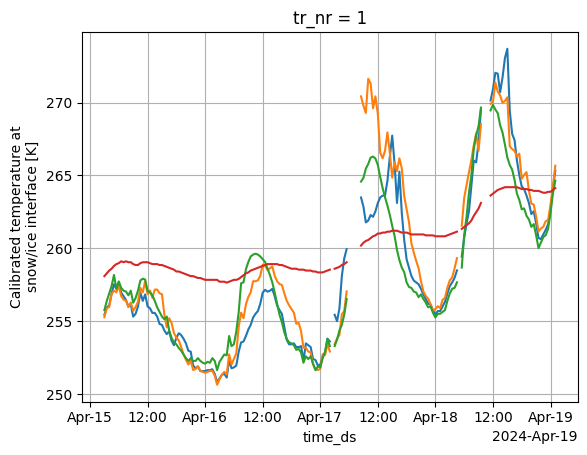

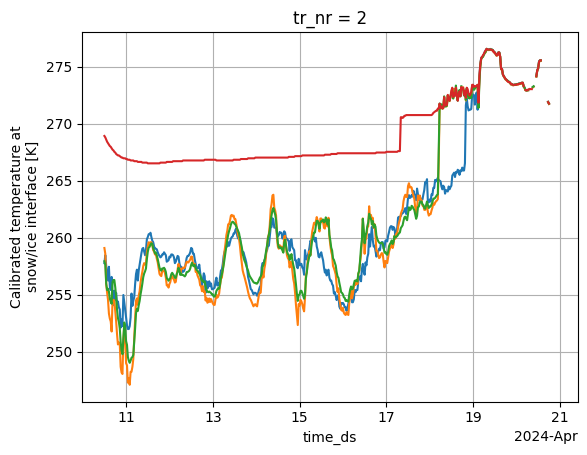

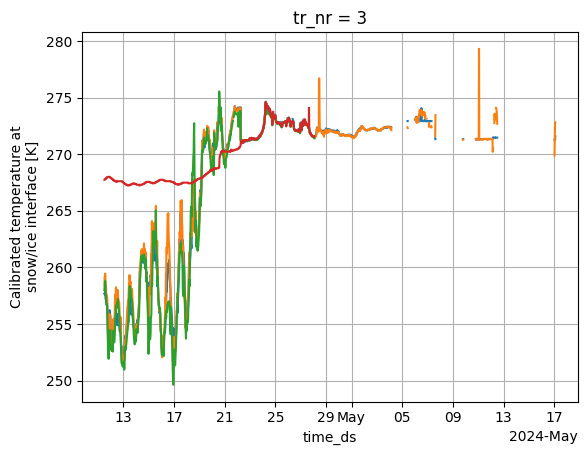

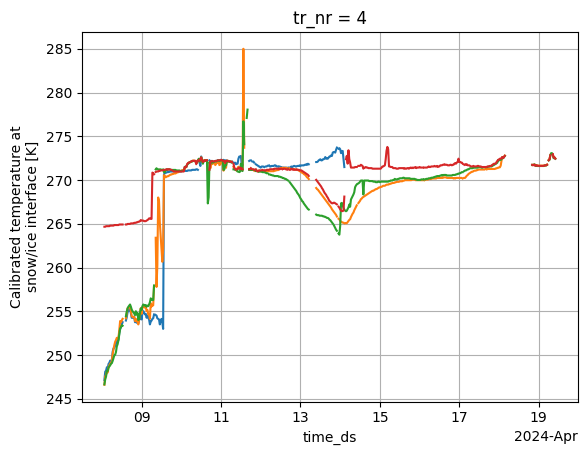

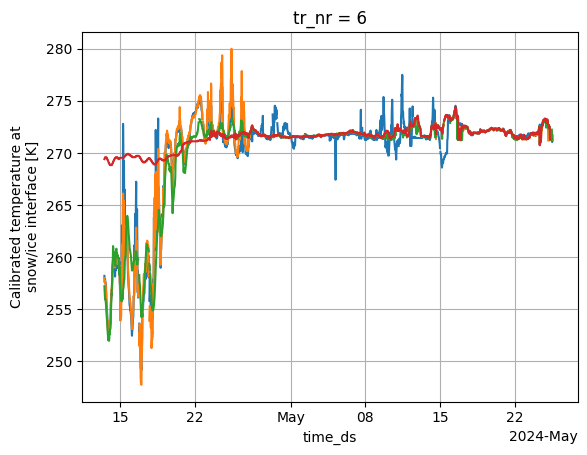

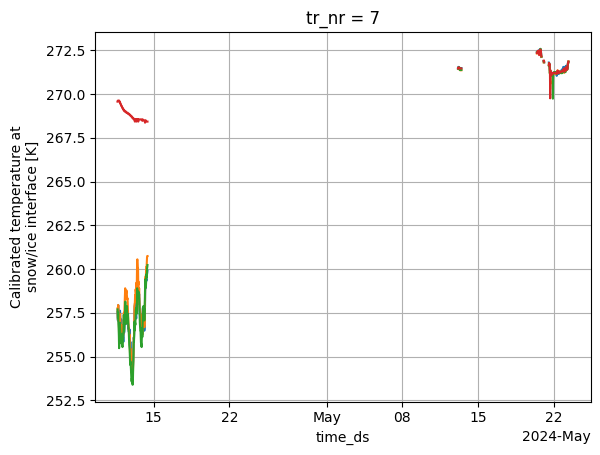

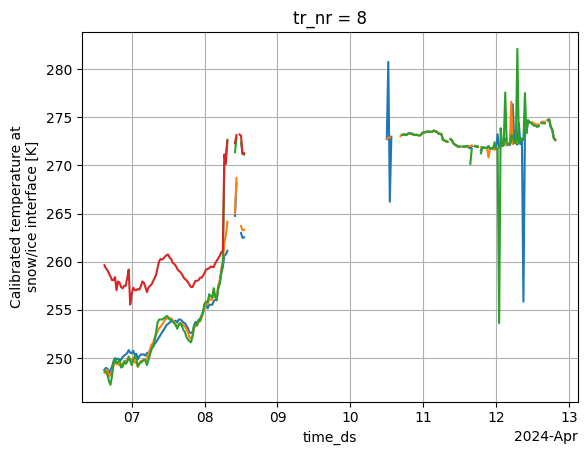

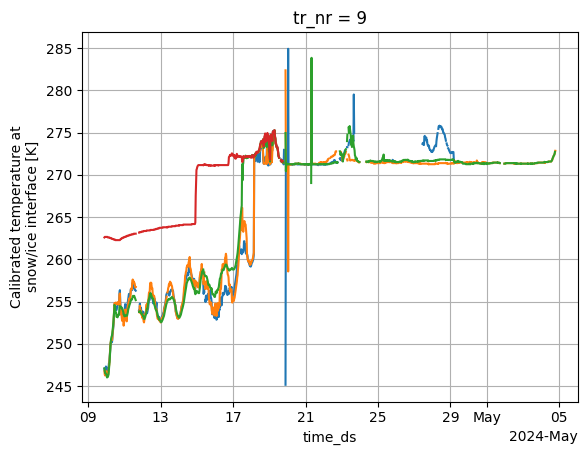

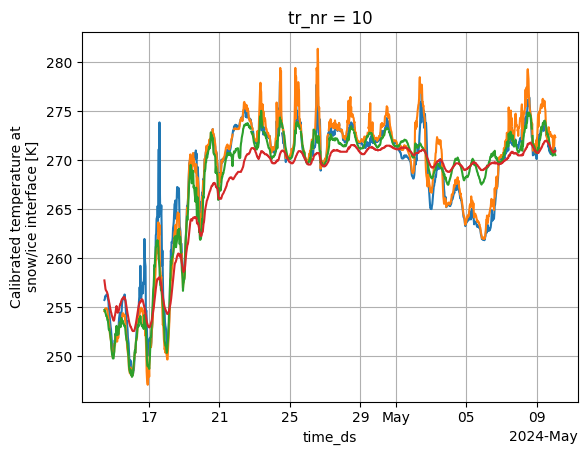

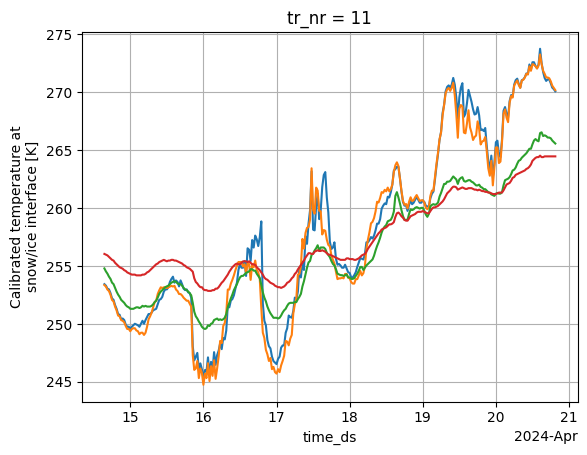

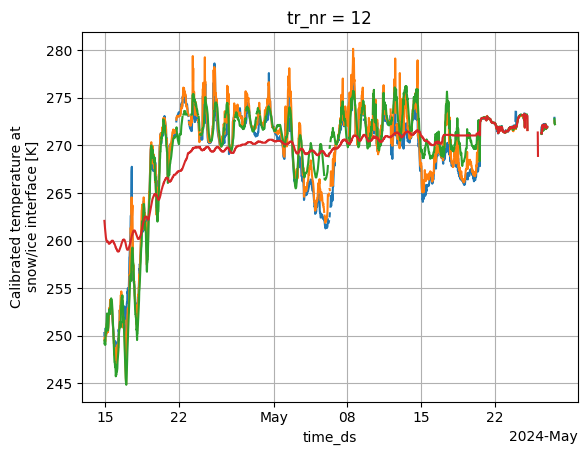

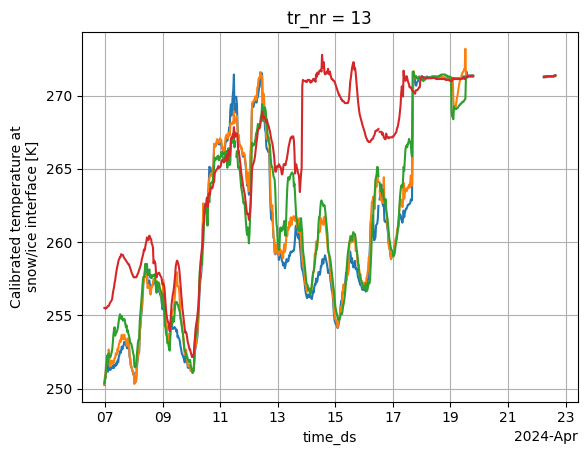

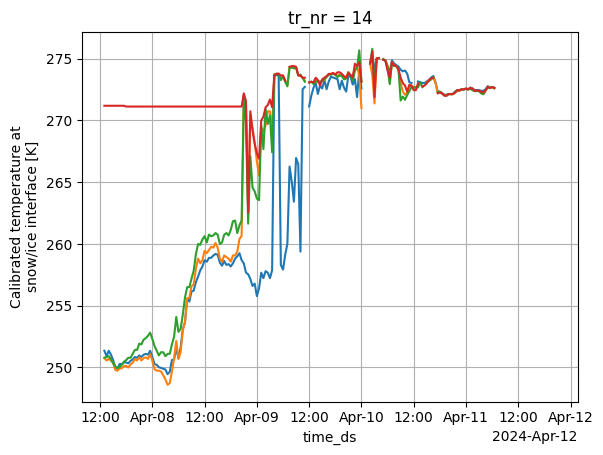

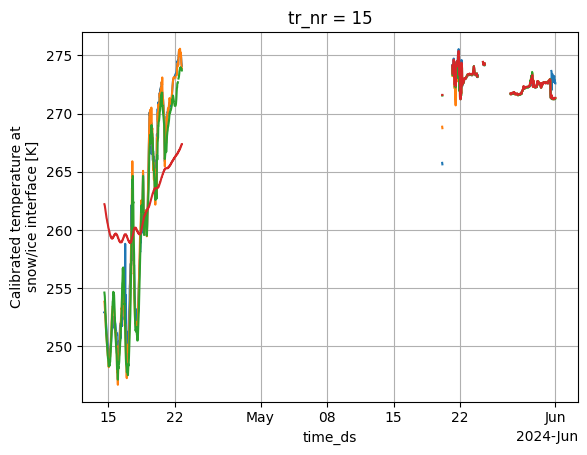

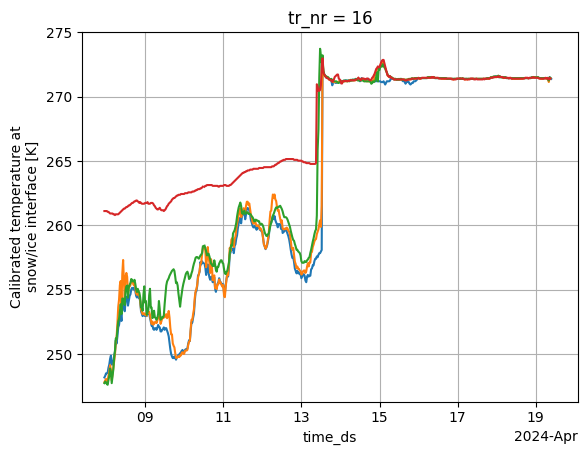

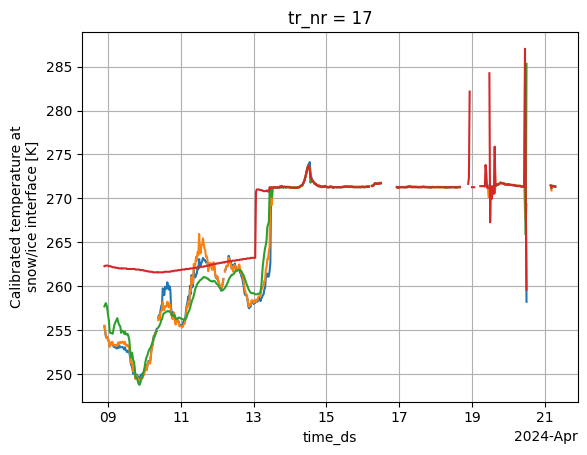

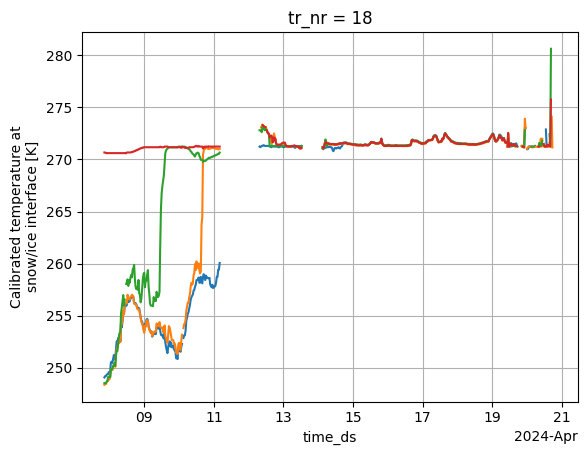

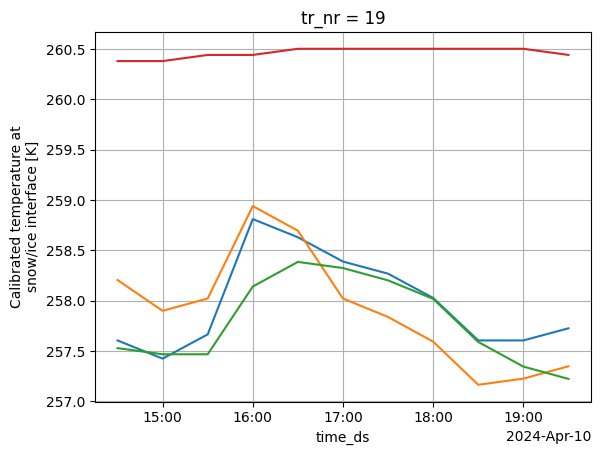

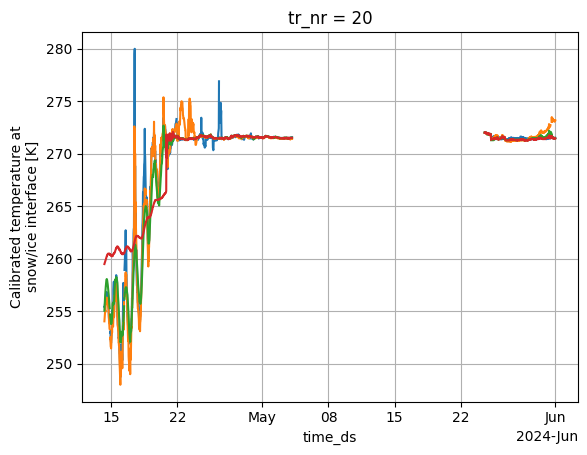

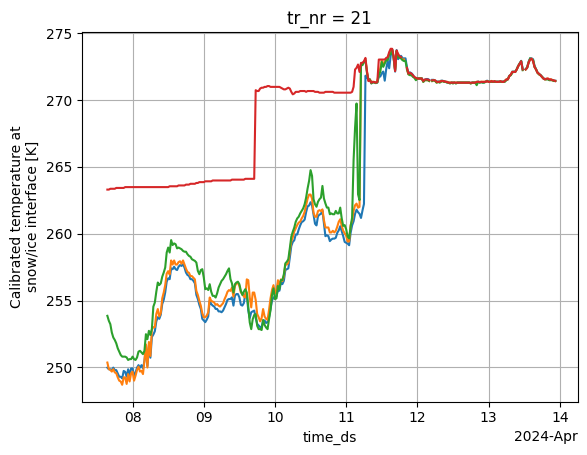

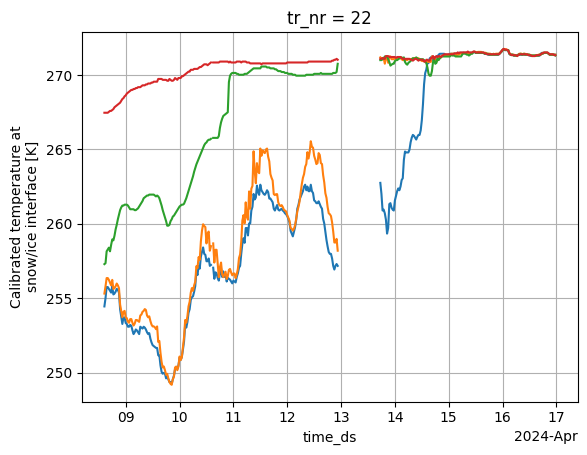

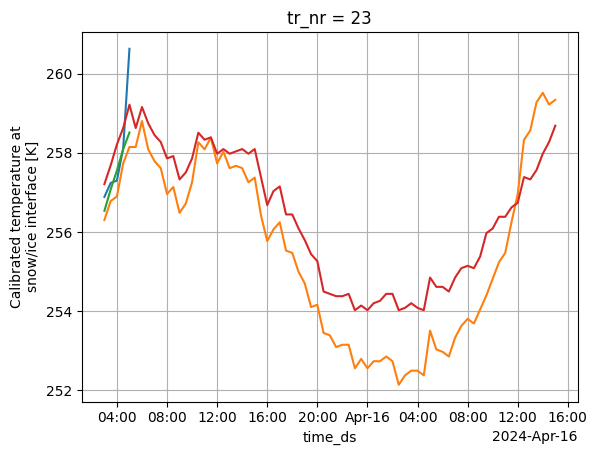

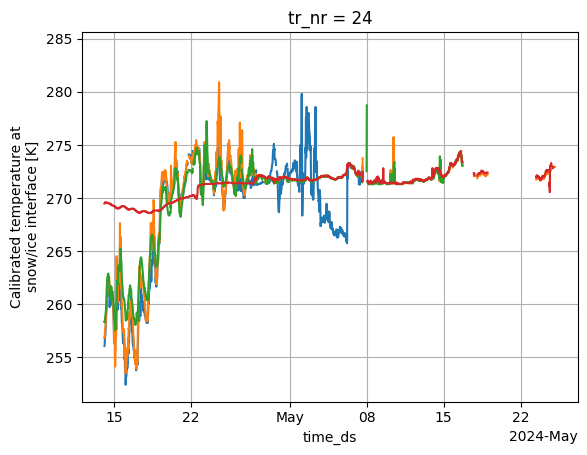

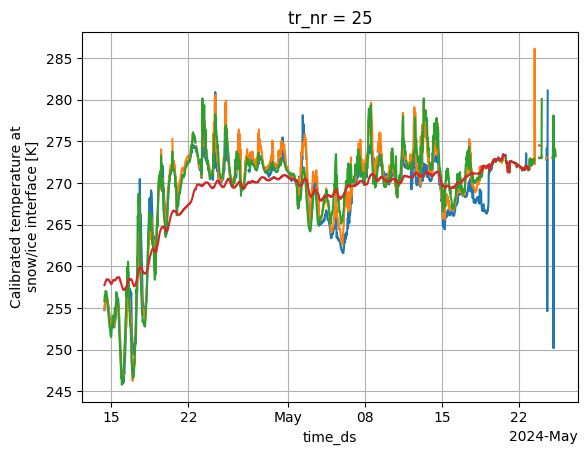

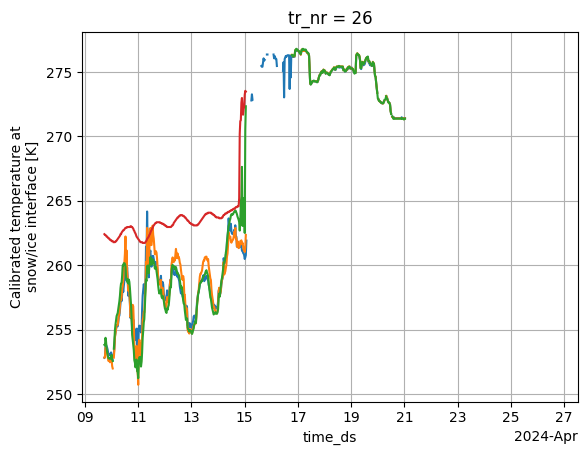

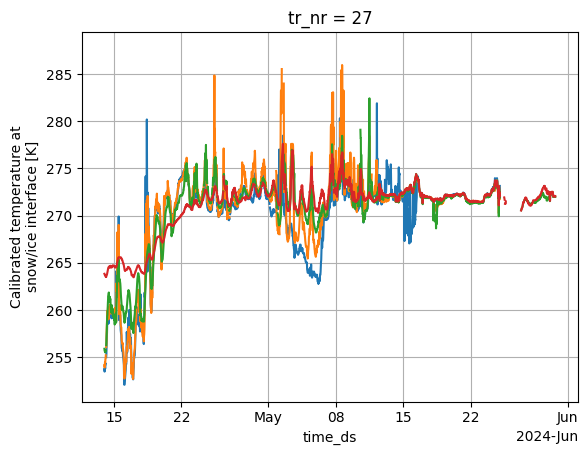

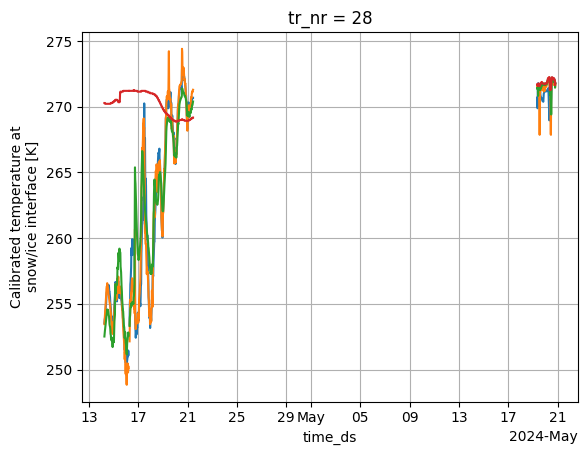

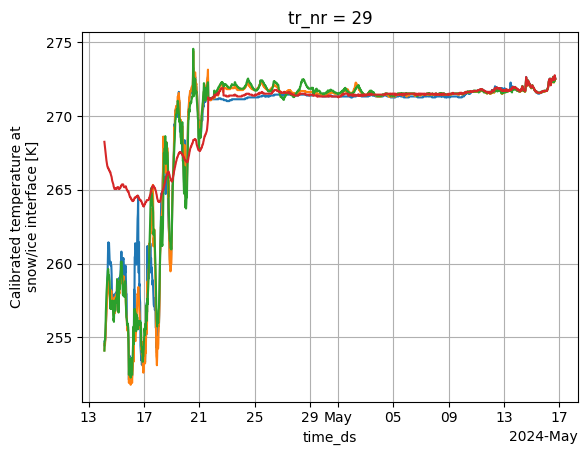

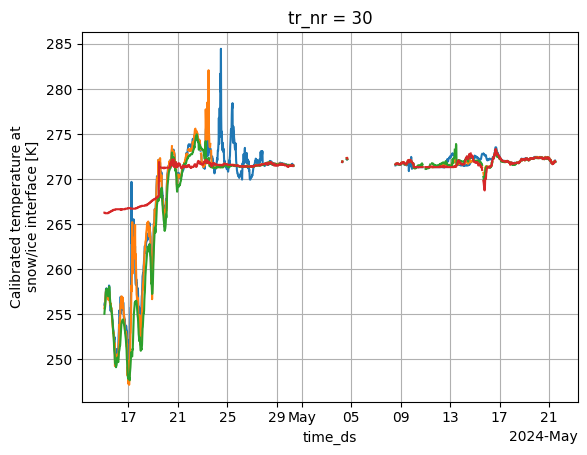

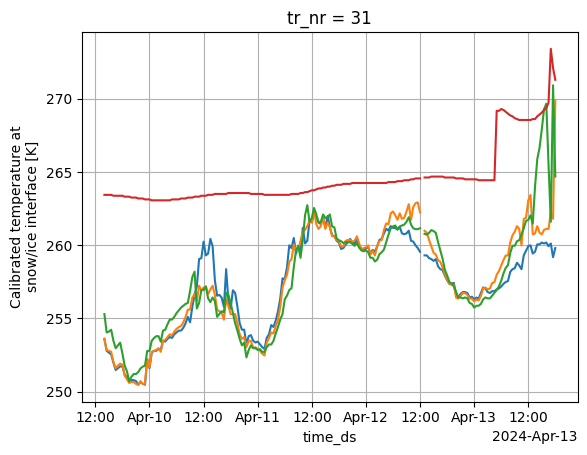

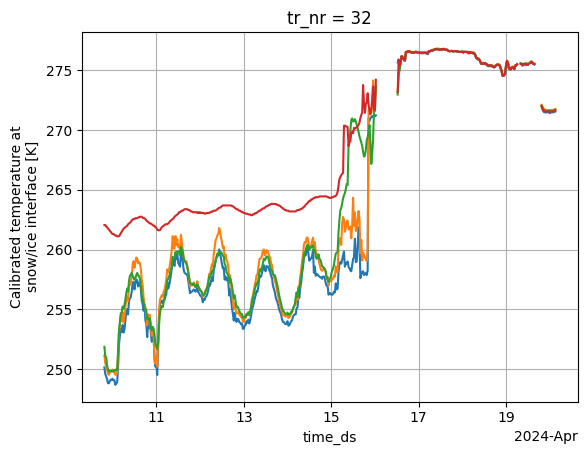

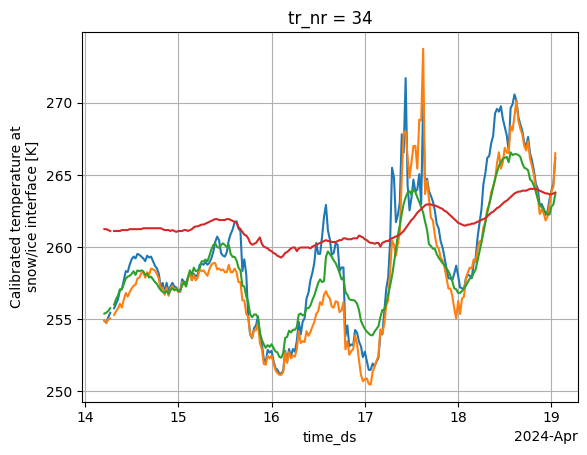

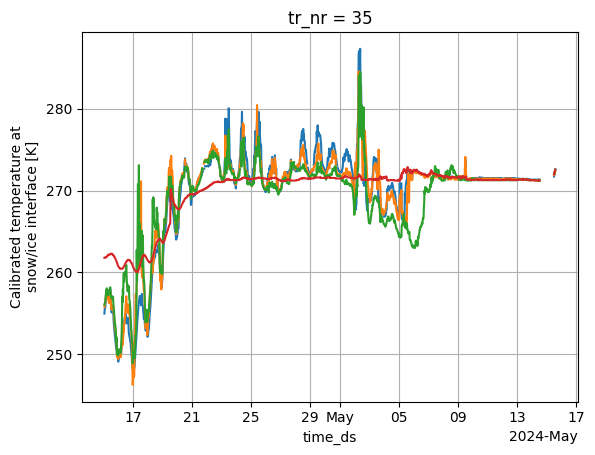

In [8]:
for i in tr_nr_values:
    plt.figure()
    dataset['temp_1m_calibrated'].sel(tr_nr=i).plot()
    dataset['temp_10cm_calibrated'].sel(tr_nr=i).plot()
    dataset['temp_snowsurface_calibrated'].sel(tr_nr=i).plot()
    dataset['temp_snowice_calibrated'].sel(tr_nr=i).plot()
    plt.grid()

## Fill overarching dataset with model data

In [9]:
def interp_map_yx(example_model_ds, key_lon, key_lat, key_x, key_y, lon_obs, lat_obs, time_ds, model):
    # e.g. for ECMWF-AIFS: only lat,lon coordinate, not in grid-structure
    keys = list(example_model_ds.data_vars) + list(example_model_ds.coords) 
    #if (key_lon not in keys) or (key_lat not in keys):
    if model == 'ECMWF-AIFS':
        print('Regridding key_lon, key_lat')
        lon_grid, lat_grid = np.meshgrid(example_model_ds[key_lon], example_model_ds[key_lat])
        example_model_ds[key_lon+'_grid'] = ((key_lat, key_lon), lon_grid)
        example_model_ds[key_lat+'_grid'] = ((key_lat, key_lon), lat_grid)
        key_lon = key_lon + '_grid'
        key_lat = key_lat + '_grid'

    yx_model = []

    # Loop through each position, find closest point (xc, yc) coordinates in model grid
    for time in time_ds:
        lon_obs_time = lon_obs.sel(time_ds=time)
        lat_obs_time = lat_obs.sel(time_ds=time)

        if np.isnan(lat_obs_time) or np.isnan(lon_obs_time):
            yx_model.append((np.nan, np.nan))
        else:
            # Determine the difference between grid lat/lon and the selected position
            c_model = np.maximum(np.abs(example_model_ds[key_lat] - lat_obs_time), np.abs(example_model_ds[key_lon] - lon_obs_time))
            # Determine the index of the point with minimal difference
            yi_model, xi_model = np.unravel_index(c_model.argmin(), c_model.shape)
            # Select corresponding xc, yc coordinates using dictionary indexing
            y_model_val = example_model_ds[key_y].isel({key_y: yi_model})
            x_model_val = example_model_ds[key_x].isel({key_x: xi_model})
            yx_model.append((y_model_val, x_model_val))
            #print(example_model_ds[key_lon].sel({key_y: y_model_val, key_x: x_model_val}).values, lon_obs_time.values)
            #print(example_model_ds[key_lat].sel({key_y: y_model_val, key_x: x_model_val}).values, lat_obs_time.values)

    # Convert the list of xc, yc values into separate y and x arrays
    y_model, x_model = zip(*yx_model)
    y_model = xr.DataArray(np.array(y_model), dims='time_ds', coords={'time_ds': time_ds})
    x_model = xr.DataArray(np.array(x_model), dims='time_ds', coords={'time_ds': time_ds})

    return y_model, x_model


Add models that should be processed in model_info

In [10]:
# Dictionary to store model-specific information
model_info = {

    'MF-AROME': {
    'file_path': "/lustre/storeB/project/nwp/SALIENSEAS/SvalMIZ2024/models/MF-AROME/AROME_SVALBARD_202404301200_202405021200.nc",
    'key_lon': 'Longitude','key_lat': 'Latitude','key_x': 'lon','key_y': 'lat'}

}


model_info_to_do = {
                'MET-Bris': {
        'file_path': "/lustre/storeB/project/nwp/SALIENSEAS/SvalMIZ2024/models/MET-Bris/infer_tln320_aa25_t2017_2022_std_lr_5k_iter_r4_20240401T00Z.nc",
        'key_lon': 'longitude','key_lat': 'latitude','key_x': 'x','key_y': 'y'},
    
        'MF-ARPEGE': {
        'file_path': "/lustre/storeB/project/nwp/SALIENSEAS/SvalMIZ2024/models/MF-ARPEGE/ARPEGE_SVALBARD_202404030000_202404051600.nc",
        'key_lon': 'Longitude','key_lat': 'Latitude','key_x': 'lon','key_y': 'lat'},
                'ECMWF-IFS': {
    'file_path': "/lustre/storeB/project/nwp/SALIENSEAS/SvalMIZ2024/models/ECMWF-IFS/Arctic.ECMWF_extracted_20240421T12Z.nc",
    'key_lon': 'lon','key_lat': 'lat','key_x': 'lon','key_y': 'lat'},

    'ECMWF-AIFS': {
        'file_path': "/lustre/storeB/project/nwp/SALIENSEAS/SvalMIZ2024/models/ECMWF-AIFS/Arctic.ECMWF_AIFS_extracted_20240530T00Z.nc",
        'key_lon': 'lon','key_lat': 'lat','key_x': 'lon','key_y': 'lat'},
        'ECCC-HRDPSN': {
    'file_path': "/lustre/storeB/project/nwp/SALIENSEAS/SvalMIZ2024/models/ECCC-HRDPSN/2024051400.nc.000001",
    'key_lon': 'nav_lon','key_lat': 'nav_lat','key_x': 'x','key_y': 'y'},     
    
            'MET-AROMEArctic': {
        'file_path': "/lustre/arkiv/arkiv-transition/archive/projects/metproduction/DNMI_AROME_ARCTIC/2024/04/15/arome_arctic_det_2_5km_20240415T00Z.nc",
        'key_lon': 'longitude','key_lat': 'latitude','key_x': 'x','key_y': 'y'},

    'MF-AROME': {
    'file_path': "/lustre/storeB/project/nwp/SALIENSEAS/SvalMIZ2024/models/MF-AROME/AROME_SVALBARD_202404301200_202405021200.nc",
    'key_lon': 'Longitude','key_lat': 'Latitude','key_x': 'lon','key_y': 'lat'},
    
    'ECCC-HRDPSNcoupled': {
    'file_path': "/lustre/storeB/project/nwp/SALIENSEAS/SvalMIZ2024/models/ECCC-HRDPSNcoupled/2024050100.nc.000001",
    'key_lon': 'nav_lon','key_lat': 'nav_lat','key_x': 'x','key_y': 'y'},  
  
    'DWD-ICON': {
        'file_path': "/lustre/storeB/project/nwp/SALIENSEAS/SvalMIZ2024/models/DWD-ICON/icon_global_2024040312_ALHFL_S.nc",
        'key_lon': 'lon','key_lat': 'lat','key_x': 'lon','key_y': 'lat'},
}


In [ ]:
# Function to process a single model
def process_model(model_name, model_data, tr_nr_values, interp_map_yx):
    global dataset
    
    file_path = model_data['file_path']
    key_lon = model_data['key_lon']
    key_lat = model_data['key_lat']
    key_x = model_data['key_x']
    key_y = model_data['key_y']

    example_model_ds = xr.open_dataset(file_path, engine="netcdf4")

    for selected_tr_nr in tr_nr_values:
        lon_obs = dataset.sel(tr_nr=selected_tr_nr)['lon_obs']
        lat_obs = dataset.sel(tr_nr=selected_tr_nr)['lat_obs']
        time_ds = dataset.time_ds
        y_model, x_model = interp_map_yx(example_model_ds, key_lon, key_lat, key_x, key_y, lon_obs, lat_obs, time_ds, model_name)
        # mask values where position is not available
        mask_nan = ~(np.isnan(x_model) + np.isnan(y_model))
            
        # Loop through lead times and update dataset
        for i in range(0, 90, 12):
            try:
                selected_lt_int = f']{i}_{i + 12}]'
                dataset_model_lt = xr.open_dataset(f"{model_name}/{model_name}_{int(i)}_{int(i + 12)}.nc")
                
                # find which times are available in the sub-selection of the forecast (rel to the overarching ds)
                av_times_fc = dataset_model_lt['time'].values
                mask_av = pd.to_datetime(time_ds).isin(pd.to_datetime(av_times_fc))
                
                if 'Wspeed' not in list(dataset_model_lt.data_vars):
                    U10M = dataset_model_lt['U10M']
                    V10M = dataset_model_lt['V10M']
                    dataset_model_lt['Wspeed'] = np.sqrt(U10M**2 + V10M**2)
                if 'Wdirection' not in list(dataset_model_lt.data_vars):
                    U10M = dataset_model_lt['U10M']
                    V10M = dataset_model_lt['V10M']
                    # https://confluence.ecmwf.int/pages/viewpage.action?pageId=133262398
                    dataset_model_lt['Wdirection'] = (180 + (180 / np.pi) * np.arctan2(U10M, V10M)) % 360
                #print(np.sum(mask_av))
                #print(np.sum(mask_nan))
                #print(np.sum(mask_av * mask_nan))
                if np.sum(mask_av * mask_nan) > 0:
                    for var in dataset_model_lt.data_vars:
                        #print(dataset_model_lt[var].sel({'time': time_ds[mask_av * mask_nan], key_x: x_model[mask_av * mask_nan], key_y: y_model[mask_av * mask_nan]}).values)
                        dataset[var].loc[dict(model=model_name, lt_int=selected_lt_int, tr_nr=selected_tr_nr, time_ds = time_ds[mask_av * mask_nan])] = \
                            dataset_model_lt[var].sel({'time': time_ds[mask_av * mask_nan], key_x: x_model[mask_av * mask_nan], key_y: y_model[mask_av * mask_nan]})
                        #print(model_name, selected_lt_int, selected_tr_nr)
                        #print(time_ds[mask_av * mask_nan])
                        #print(dataset[var].loc[dict(model=model_name, lt_int=selected_lt_int, tr_nr=selected_tr_nr, time_ds = time_ds[mask_av * mask_nan])])
                dataset_model_lt.close()
                print(f"Successfully processed {model_name}, lead time {i} to {i + 12} for {selected_tr_nr}.")
            except FileNotFoundError:
                print(f"Dataset for model {model_name}, lead time {i} to {i + 12} not found.")
    
global dataset
for model_name, model_data in model_info.items():
    process_model(model_name, model_data, tr_nr_values, interp_map_yx)



Successfully processed MF-AROME, lead time 0 to 12 for 1.
Successfully processed MF-AROME, lead time 12 to 24 for 1.
Successfully processed MF-AROME, lead time 24 to 36 for 1.
Successfully processed MF-AROME, lead time 36 to 48 for 1.
Dataset for model MF-AROME, lead time 48 to 60 not found.
Dataset for model MF-AROME, lead time 60 to 72 not found.
Dataset for model MF-AROME, lead time 72 to 84 not found.
Dataset for model MF-AROME, lead time 84 to 96 not found.
Successfully processed MF-AROME, lead time 0 to 12 for 2.
Successfully processed MF-AROME, lead time 12 to 24 for 2.
Successfully processed MF-AROME, lead time 24 to 36 for 2.
Successfully processed MF-AROME, lead time 36 to 48 for 2.
Dataset for model MF-AROME, lead time 48 to 60 not found.
Dataset for model MF-AROME, lead time 60 to 72 not found.
Dataset for model MF-AROME, lead time 72 to 84 not found.
Dataset for model MF-AROME, lead time 84 to 96 not found.
Successfully processed MF-AROME, lead time 0 to 12 for 3.
Successf

In [ ]:
dataset.to_netcdf('dataset_MF-AROME.nc')

### Some corrections if necessary

In [ ]:
dataset_hrdpsn = xr.open_dataset('dataset_ECCC-HRDPSN.nc')
dataset_hrdpsn_coupled = xr.open_dataset('dataset_ECCC-HRDPSNcoupled.nc')

In [ ]:
dataset_hrdpsn['T2M'].loc[dict(model='ECCC-HRDPSN')] = dataset_hrdpsn['T2M'].sel(model='ECCC-HRDPSN')+273.15
dataset_hrdpsn['Tl1'].loc[dict(model='ECCC-HRDPSN')] = dataset_hrdpsn['Tl1'].sel(model='ECCC-HRDPSN')+273.15
dataset_hrdpsn_coupled['T2M'].loc[dict(model='ECCC-HRDPSNcoupled')] = dataset_hrdpsn_coupled['T2M'].sel(model='ECCC-HRDPSNcoupled')+273.15
dataset_hrdpsn_coupled['Tl1'].loc[dict(model='ECCC-HRDPSNcoupled')] = dataset_hrdpsn_coupled['Tl1'].sel(model='ECCC-HRDPSNcoupled')+273.15

## Check if all models are included: plot

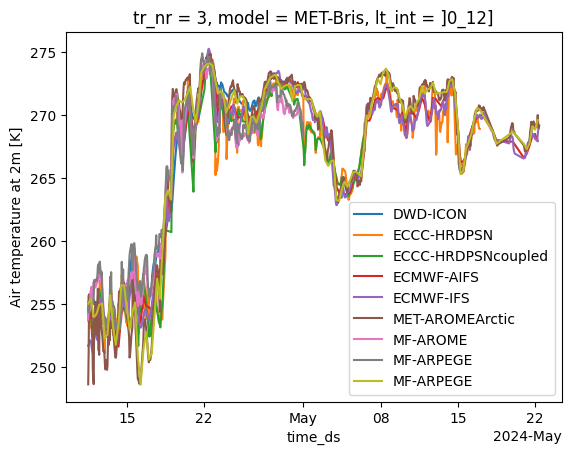

In [27]:
tr_nr = 3
dataset['T2M'].sel(model='DWD-ICON', tr_nr = tr_nr, lt_int = ']0_12]' ).dropna(dim='time_ds', how='any').plot(label='DWD-ICON')
dataset['T2M'].sel(model='ECCC-HRDPSN', tr_nr = tr_nr, lt_int = ']0_12]' ).dropna(dim='time_ds', how='any').plot(label='ECCC-HRDPSN')
dataset['T2M'].sel(model='ECCC-HRDPSNcoupled', tr_nr = tr_nr, lt_int = ']0_12]' ).dropna(dim='time_ds', how='any').plot(label='ECCC-HRDPSNcoupled')
dataset['T2M'].sel(model='ECMWF-AIFS', tr_nr = tr_nr, lt_int = ']0_12]' ).dropna(dim='time_ds', how='any').plot(label='ECMWF-AIFS')
dataset['T2M'].sel(model='ECMWF-IFS', tr_nr = tr_nr, lt_int = ']0_12]' ).dropna(dim='time_ds', how='any').plot(label='ECMWF-IFS')
dataset['T2M'].sel(model='MET-AROMEArctic', tr_nr = tr_nr, lt_int = ']0_12]' ).dropna(dim='time_ds', how='any').plot(label='MET-AROMEArctic')
dataset['T2M'].sel(model='MF-AROME', tr_nr = tr_nr, lt_int = ']0_12]' ).dropna(dim='time_ds', how='any').plot(label='MF-AROME')
dataset['T2M'].sel(model='MF-ARPEGE', tr_nr = tr_nr, lt_int = ']0_12]' ).dropna(dim='time_ds', how='any').plot(label='MF-ARPEGE')
dataset['T2M'].sel(model='MET-Bris', tr_nr = tr_nr, lt_int = ']0_12]' ).dropna(dim='time_ds', how='any').plot(label='MF-ARPEGE')

plt.legend()

In [3]:

dataset=xr.open_dataset('dataset_temp_AIFS_ICON_AROMEArctic_ARPEGE_IFS_AROME_HRDPSN.nc')

## Add flags from atmospher_pre

In [4]:
temp_flag_cons = {}
temp_flag_cons[1] = np.datetime64('2024-04-19T01:30')
temp_flag_cons[2] = np.datetime64('2024-04-17T07:30')
temp_flag_cons[3] = np.datetime64('2024-04-22T01:00')
temp_flag_cons[4] = np.datetime64('2024-04-09T06:00')
temp_flag_cons[6] = np.datetime64('2024-04-27T10:00')
temp_flag_cons[7] = np.datetime64('2024-04-14T10:00')
temp_flag_cons[8] = np.datetime64('2024-04-07T22:30')
temp_flag_cons[9] = np.datetime64('2024-04-14T21:30')
temp_flag_cons[10] = np.datetime64('2024-05-10T02:00')
temp_flag_cons[11] = np.datetime64('2024-04-20T19:30')
temp_flag_cons[12] = np.datetime64('2024-05-17T04:30')
temp_flag_cons[13] = np.datetime64('2024-04-09T06:00')
temp_flag_cons[14] = np.datetime64('2024-04-08T20:00')
temp_flag_cons[15] = np.datetime64('2024-04-22T17:30')
temp_flag_cons[16] = np.datetime64('2024-04-13T09:00')
temp_flag_cons[17] = np.datetime64('2024-04-13T00:30')
temp_flag_cons[18] = np.datetime64('2024-04-09T00:00')
temp_flag_cons[19] = np.datetime64('2024-04-10T19:30')
temp_flag_cons[20] = np.datetime64('2024-04-20T19:00')
temp_flag_cons[21] = np.datetime64('2024-04-09T17:00')
temp_flag_cons[22] = np.datetime64('2024-04-12T22:30')
temp_flag_cons[23] = np.datetime64('2024-04-16T15:00')
temp_flag_cons[24] = np.datetime64('2024-04-22T07:00')
temp_flag_cons[25] = np.datetime64('2024-05-18T15:00')
temp_flag_cons[26] = np.datetime64('2024-04-14T18:30')
temp_flag_cons[27] = np.datetime64('2024-05-17T00:30')
temp_flag_cons[28] = np.datetime64('2024-04-21T10:30')
temp_flag_cons[29] = np.datetime64('2024-04-21T15:00')
temp_flag_cons[30] = np.datetime64('2024-04-19T09:30')
temp_flag_cons[31] = np.datetime64('2024-04-13T04:30')
temp_flag_cons[32] = np.datetime64('2024-04-15T06:30')
temp_flag_cons[34] = np.datetime64('2024-04-19T01:00')
temp_flag_cons[35] = np.datetime64('2024-05-05T13:00')

In [5]:
temp_flag_1m = {}
temp_flag_1m[1] = np.datetime64('2024-04-19T01:30')
temp_flag_1m[2] = np.datetime64('2024-04-18T19:00')
temp_flag_1m[3] = np.datetime64('2024-04-22T01:00')
temp_flag_1m[4] = np.datetime64('2024-04-09T13:00')
temp_flag_1m[6] = np.datetime64('2024-05-01T12:00')
temp_flag_1m[7] = np.datetime64('2024-04-14T10:00')
temp_flag_1m[8] = np.datetime64('2024-04-07T22:30')
temp_flag_1m[9] = np.datetime64('2024-04-18T02:30')
temp_flag_1m[10] = np.datetime64('2024-05-10T02:00')
temp_flag_1m[11] = np.datetime64('2024-04-20T19:30')
temp_flag_1m[12] = np.datetime64('2024-05-20T14:00')
temp_flag_1m[13] = np.datetime64('2024-04-17T15:30')
temp_flag_1m[14] = np.datetime64('2024-04-09T03:31')
temp_flag_1m[15] = np.datetime64('2024-04-22T17:30')
temp_flag_1m[16] = np.datetime64('2024-04-13T12:30')
temp_flag_1m[17] = np.datetime64('2024-04-13T10:30')
temp_flag_1m[18] = np.datetime64('2024-04-11T03:00')
temp_flag_1m[19] = np.datetime64('2024-04-10T19:30')
temp_flag_1m[20] = np.datetime64('2024-04-21T23:00')
temp_flag_1m[21] = np.datetime64('2024-04-11T06:00')
temp_flag_1m[22] = np.datetime64('2024-04-12T22:30')
temp_flag_1m[23] = np.datetime64('2024-04-16T15:00')
temp_flag_1m[24] = np.datetime64('2024-05-01T19:00')
temp_flag_1m[25] = np.datetime64('2024-05-19T03:30')
temp_flag_1m[26] = np.datetime64('2024-04-15T02:00')
temp_flag_1m[27] = np.datetime64('2024-05-17T00:30')
temp_flag_1m[28] = np.datetime64('2024-04-21T10:30')
temp_flag_1m[29] = np.datetime64('2024-04-21T15:00')
temp_flag_1m[30] = np.datetime64('2024-04-23T04:00')
temp_flag_1m[31] = np.datetime64('2024-04-13T18:00')
temp_flag_1m[32] = np.datetime64('2024-04-15T19:30')
temp_flag_1m[34] = np.datetime64('2024-04-19T01:00')
temp_flag_1m[35] = np.datetime64('2024-05-05T13:00')

In [8]:
dataset['temp_flag_cons'] = (('tr_nr', 'time_ds'), np.nan*np.zeros((len(tr_nr_values), len(dataset.time_ds))))
dataset['temp_flag_1m'] = (('tr_nr', 'time_ds'), np.nan*np.zeros((len(tr_nr_values), len(dataset.time_ds))))
for i in tr_nr_values:
    dataset['temp_flag_cons'].loc[{'tr_nr': i}] = (dataset.time_ds > temp_flag_cons[i])
    dataset['temp_flag_1m'].loc[{'tr_nr': i}] = (dataset.time_ds > temp_flag_1m[i])

In [9]:
dataset.to_netcdf('dataset_temp_AIFS_ICON_AROMEArctic_ARPEGE_IFS_AROME_HRDPSN_flags.nc')

In [ ]:
atm_ds = xr.open_dataset('atm_dataset_temp.nc')

In [ ]:
model_sel = 'ECCC-HRDPSN'
lt_int_sel = ']0_12]'
tr_nr_selected = 6
temp_comp_sel = 'T2M'
atm_ds[temp_comp_sel].sel(tr_nr=tr_nr_selected, lt_int=lt_int_sel, model=model_sel).plot()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

# Function to calculate RMSE
def calculate_rmse(y_true, y_pred):
    nan_mask = np.isnan(y_true) | np.isnan(y_pred)
    if np.sum(~nan_mask) != 0:
        return np.sqrt(mean_squared_error(y_true[~nan_mask], y_pred[~nan_mask]))
    else:
        return np.nan

# Function to calculate bias
def calculate_bias(y_true, y_pred):
    nan_mask = np.isnan(y_true) | np.isnan(y_pred)
    if np.sum(~nan_mask) != 0:
        return np.mean(y_pred[~nan_mask] - y_true[~nan_mask])
    else:
        return np.nan

temp_comp_sel = 'T2M'
# Initialize structure for results
results = {}

# Loop through lt_int values
for lt_int_sel in lt_int_values:
    results[lt_int_sel] = {}
    
    # Loop through models
    for model_sel in model_names:
        model_results = {}
        
        # Loop through tr_nr values
        for tr_nr_selected in tr_nr_values:
            # Extract the data
            temp_1m_calibrated = atm_ds['temp_1m_calibrated'].sel(tr_nr=tr_nr_selected)
            temp_flag_cons = atm_ds['temp_flag_cons'].sel(tr_nr=tr_nr_selected)
            temp_flag_1m = atm_ds['temp_flag_1m'].sel(tr_nr=tr_nr_selected)
            temp_comp = atm_ds[temp_comp_sel].sel(tr_nr=tr_nr_selected, lt_int=lt_int_sel, model=model_sel)
            
            # Calculate metrics where temp_flag_1m is False
            valid_indices_1m = (temp_flag_1m == 0)
            rmse_1m = calculate_rmse(temp_1m_calibrated[valid_indices_1m], temp_comp[valid_indices_1m]-273.15)
            bias_1m = calculate_bias(temp_1m_calibrated[valid_indices_1m], temp_comp[valid_indices_1m]-273.15)
            
            # Calculate metrics where temp_flag_cons is False
            valid_indices_cons = (temp_flag_cons == 0)
            rmse_cons = calculate_rmse(temp_1m_calibrated[valid_indices_cons], temp_comp[valid_indices_cons]-273.15)
            bias_cons = calculate_bias(temp_1m_calibrated[valid_indices_cons], temp_comp[valid_indices_cons]-273.15)
            
            # Store the results
            model_results[tr_nr_selected] = {
                'rmse': (rmse_1m, rmse_cons),
                'bias': (bias_1m, bias_cons)
            }
        
        if any(not all(np.isnan([results['rmse'][0], results['bias'][0]])) for results in model_results.values()):
            results[lt_int_sel][model_sel] = model_results

# Create and print the table
table = pd.DataFrame(columns=tr_nr_values)
for lt_int_sel in lt_int_values:
    for model_sel, model_results in results.get(lt_int_sel, {}).items():
        for tr_nr_selected, metrics in model_results.items():
            row_name = f"{lt_int_sel}_{model_sel}"
            table.at[row_name, tr_nr_selected] = (
                f"RMSE: {metrics['rmse'][0]:.2f} ({metrics['rmse'][1]:.2f}), "
                f"Bias: {metrics['bias'][0]:.2f} ({metrics['bias'][1]:.2f})"
            )

print(table)
